# Analyse exploratoire des données (EDA)

Jeu de données **Credit Card Fraud Detection** (Kaggle).
Objectif : comprendre la structure, le déséquilibre des classes et
les relations entre les features avant de modéliser.


In [1]:
import sys
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ajout du dossier src au chemin pour réutiliser nos fonctions
sys.path.insert(0, os.path.abspath('../src'))
from preprocessing import load_data

sns.set_theme(style='whitegrid')
%matplotlib inline


## 1. Chargement des données


In [2]:
df = load_data('../data/creditcard.csv')
df.head()


Données chargées : 284807 transactions, 31 colonnes.


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
print(f'Nombre de transactions : {df.shape[0]:,}')
print(f'Nombre de colonnes     : {df.shape[1]}\n')
df.info()


Nombre de transactions : 284,807
Nombre de colonnes     : 31

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 2

## 2. Statistiques descriptives


In [4]:
df.describe()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## 3. Distribution des classes

Le jeu de données est **extrêmement déséquilibré** : attendu ~0,17 % de fraudes.


Class
0    284315
1       492
Name: count, dtype: int64
Pourcentage de fraudes : 0.1727 %


/tmp/ipykernel_12583/2869663719.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['Normale (0)', 'Fraude (1)'])


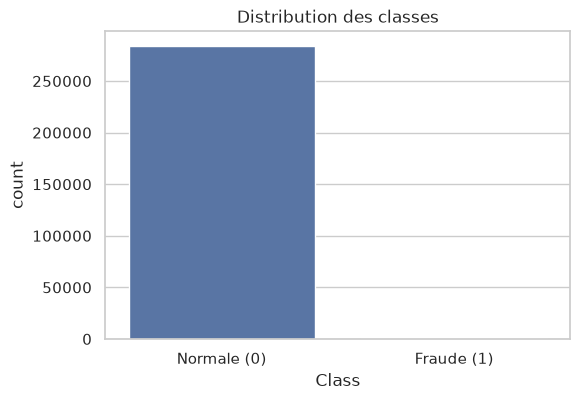

In [5]:
counts = df['Class'].value_counts()
print(counts)
print(f"Pourcentage de fraudes : {counts[1] / counts.sum() * 100:.4f} %")

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x='Class', ax=ax)
ax.set_xticklabels(['Normale (0)', 'Fraude (1)'])
ax.set_title('Distribution des classes')
plt.show()


## 4. Analyse des montants


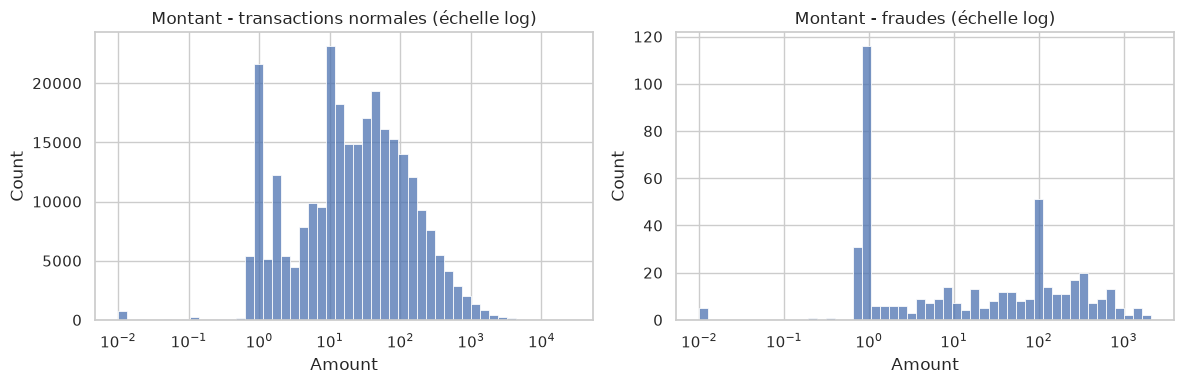

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df[df['Class'] == 0]['Amount'], bins=50, ax=axes[0], log_scale=True)
axes[0].set_title('Montant - transactions normales (échelle log)')
sns.histplot(df[df['Class'] == 1]['Amount'], bins=50, ax=axes[1], log_scale=True)
axes[1].set_title('Montant - fraudes (échelle log)')
plt.tight_layout()
plt.show()


In [7]:
df.groupby('Class')['Amount'].describe()


,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


## 5. Analyse temporelle


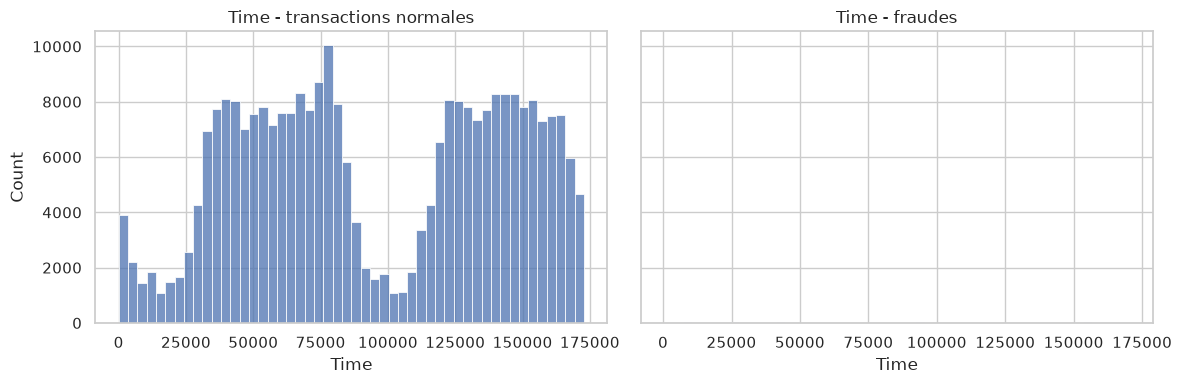

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
sns.histplot(df[df['Class'] == 0]['Time'], bins=50, ax=axes[0])
axes[0].set_title('Time - transactions normales')
sns.histplot(df[df['Class'] == 1]['Time'], bins=50, ax=axes[1])
axes[1].set_title('Time - fraudes')
plt.tight_layout()
plt.show()


## 6. Corrélations avec la cible


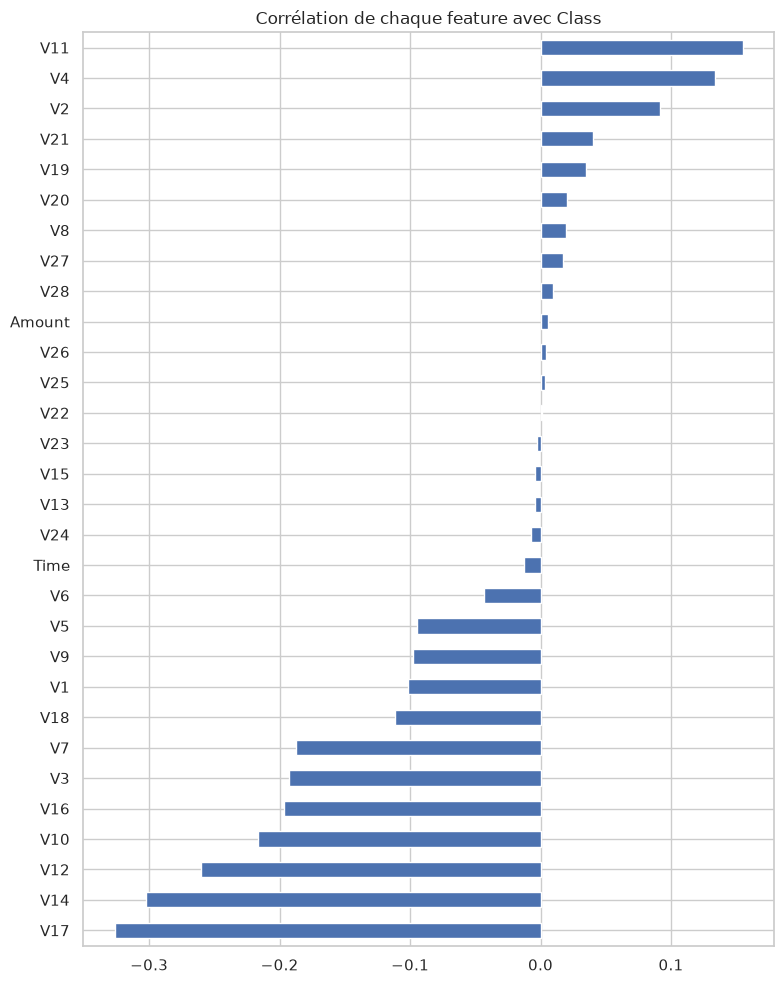

In [9]:
corr = df.drop(columns=['Class']).corrwith(df['Class']).sort_values()
corr.plot(kind='barh', figsize=(8, 10))
plt.title('Corrélation de chaque feature avec Class')
plt.tight_layout()
plt.show()


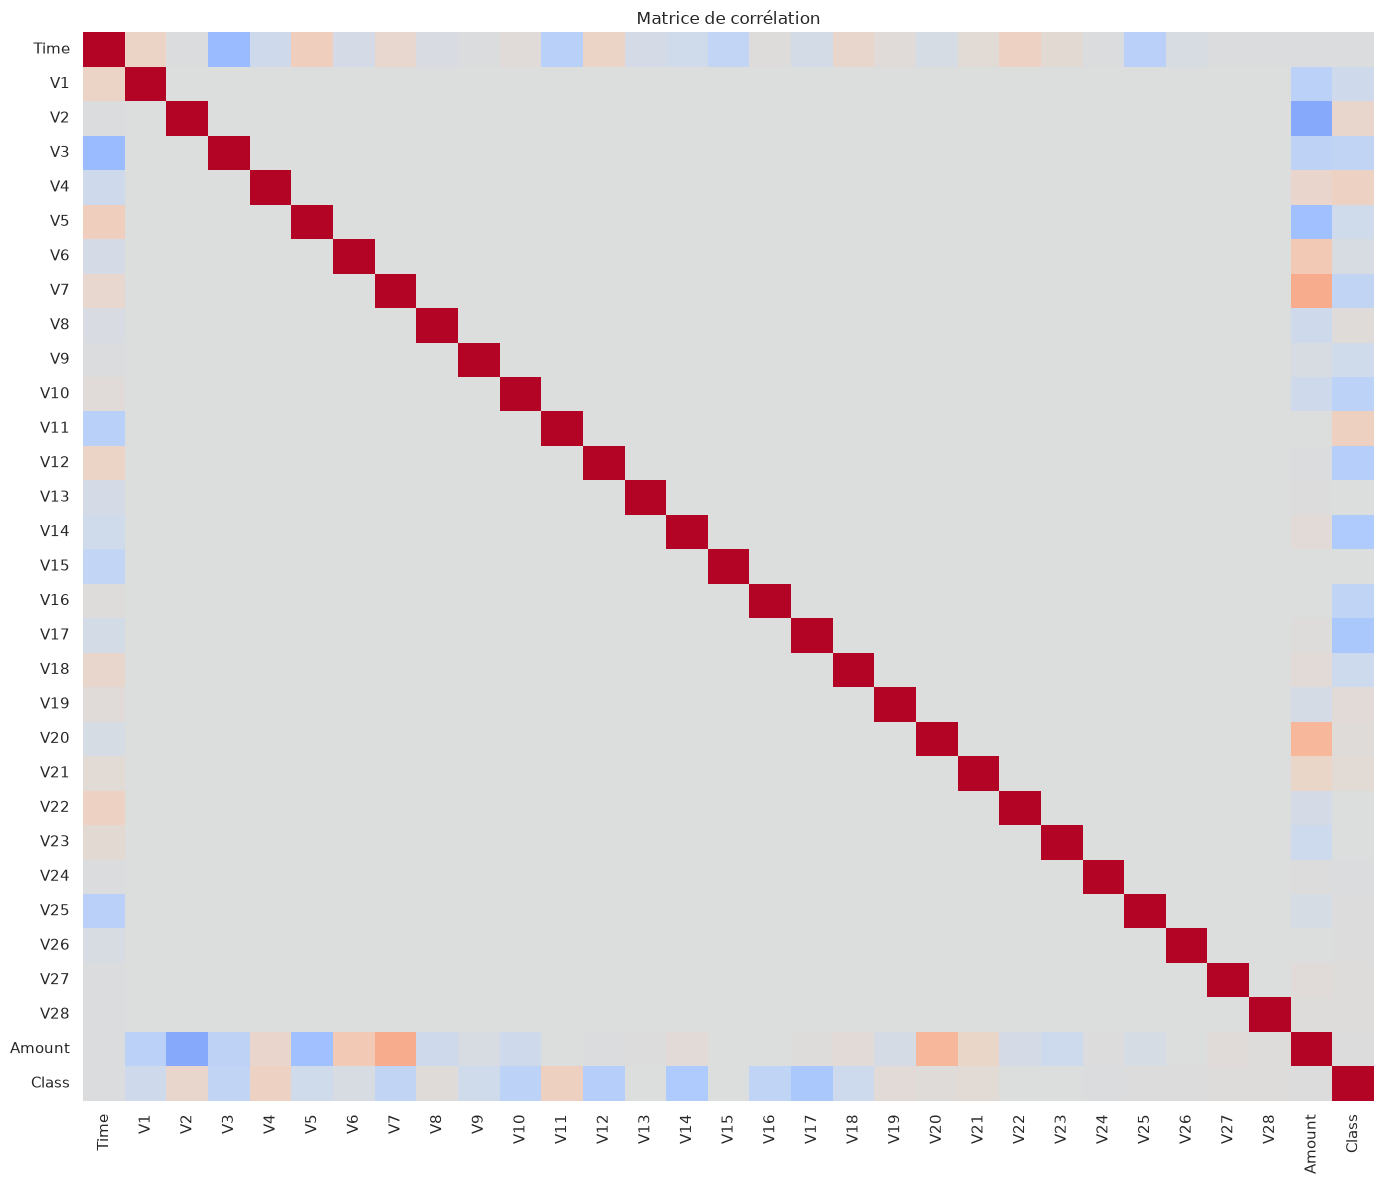

In [10]:
plt.figure(figsize=(14, 12))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm', center=0, cbar=False)
plt.title('Matrice de corrélation')
plt.tight_layout()
plt.show()


## 7. Conclusion

- Classe fortement déséquilibrée : **il faudra des métriques orientées**
  **classes minoritaires** (Rappel, Precision, PR-AUC) et une gestion
  du déséquilibre (class_weight / SMOTE).
- Les montants sont très variables → **standardisation** nécessaire.
- Les composantes V1-V28 sont déjà centrées-réduites.
- `Time` présente des motifs, signe d'une dépendance temporelle.
